In [1]:
import torch
from PIL import Image
import requests
from transformers import CLIPProcessor, CLIPModel

# Load model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Load image
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(image_url, stream=True).raw)

# Prepare text candidates
texts = ["a photo of a cat", "a photo of a dog", "a photo of a car"]

# Process inputs
inputs = processor(text=texts, images=image, return_tensors="pt", padding=True)

# Get model outputs
outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1)  # probabilities

# Print results
for i, text in enumerate(texts):
    print(f"{text}: {probs[0][i].item():.3f}")

2025-05-12 15:05:21.544241: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747062321.736510      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747062321.791825      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

a photo of a cat: 0.993
a photo of a dog: 0.005
a photo of a car: 0.002


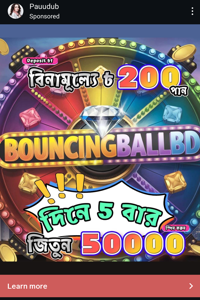

In [16]:
from PIL import Image


img = Image.open('/kaggle/input/trying/ff.png')
img = img.resize((200,300))

img

In [17]:
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

# Load and resize the image
img = Image.open('/kaggle/input/trying1/Screenshot_20250504_210228.jpg')
img = img.resize((200, 300))

# Load BLIP model and processor
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Generate caption - use the image directly
inputs = processor(img, return_tensors="pt")
output = model.generate(**inputs)
caption = processor.decode(output[0], skip_special_tokens=True)
print(f"Generated caption: {caption}")

Generated caption: a woman holding a cell phone with a video player on it


In [28]:
import pytesseract
from PIL import Image
import cv2
import numpy as np

# Configure Tesseract for Bengali
custom_config = r'--oem 1 --psm 6 -l ben'  # Use PSM 6 for block of text

def preprocess_bengali_text(image_path):
    # Read image
    img = cv2.imread(image_path)
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply adaptive thresholding - works better for Bengali script
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                  cv2.THRESH_BINARY_INV, 11, 2)
    
    # Remove noise
    kernel = np.ones((1, 1), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    
    # Dilate to connect components of Bengali characters (important for compound characters)
    kernel = np.ones((2, 2), np.uint8)
    dilated = cv2.dilate(opening, kernel, iterations=1)
    
    # Invert back for OCR
    processed = cv2.bitwise_not(dilated)
    
    return processed

# Process and extract
image_path = '/kaggle/input/trying/ff.png'
processed_img = preprocess_bengali_text(image_path)

# Save processed image for inspection
cv2.imwrite('processed_bengali.jpg', processed_img)

# Extract text
text = pytesseract.image_to_string(processed_img, config=custom_config)
print("Extracted Bengali text:")
print(text)

TesseractError: (1, 'Error opening data file /usr/share/tesseract-ocr/4.00/tessdata/ben.traineddata Please make sure the TESSDATA_PREFIX environment variable is set to your "tessdata" directory. Failed loading language \'ben\' Tesseract couldn\'t load any languages! Could not initialize tesseract.')

In [26]:
results

[([[151, 8], [318, 8], [318, 59], [151, 59]], '?৩৩ঐশ৮', 0.0027335195079077113),
 ([[152, 68], [321, 68], [321, 111], [152, 111]],
  '$ত|1ত|[২ঐ',
  0.02738189866320553),
 ([[136, 308], [285, 308], [285, 350], [136, 350]],
  '03[9390)',
  0.03178195003848268),
 ([[120, 339], [965, 339], [965, 520], [120, 520]],
  'বিরমূলল্য ট{00',
  0.06568692499726732),
 ([[889, 457], [1003, 457], [1003, 525], [889, 525]], 'পণ', 0.334517368953884),
 ([[0, 669], [1059, 669], [1059, 892], [0, 892]],
  '০০3ঢঢ8!',
  0.010330390248849793),
 ([[170, 1070], [617, 1070], [617, 1258], [170, 1258]],
  'দৌদঞ 5',
  0.31392935856618653),
 ([[872, 1212], [986, 1212], [986, 1244], [872, 1244]],
  '{িিন্যকরী',
  0.16228965708043805),
 ([[113, 1230], [987, 1230], [987, 1405], [113, 1405]],
  'জিতম 50000',
  0.22422325423070782),
 ([[35, 1521], [255, 1521], [255, 1563], [35, 1563]],
  '_ঙ৯ণ শতসঙ',
  0.01204741048711589),
 ([[643.9698835520326, 1068.0331950565046],
   [884.4534853957547, 1124.8539429426023],
   [848.03011